# Chatbot-memory

### Memory : Memory is a cognitive function that allows people to store, retrieve, and use information to understand their present and future.

#### Short‑term = per thread (checkpointer).
#### Long‑term = shared, cross‑thread (store).

### Goal: long-term memories will be used to create a personalized chatbot that can remember facts about the user.

- build a chatbot that uses both **short-term (within-thread) and long-term (across-thread) memory**.
- Save the memory in the **hot-path** while suer is interacting with it.

#### Long-term Memory :  **Store**

## Introduction to the LangGraph Store
- The LangGraph Memory Store provides a **way to store and retrieve information across threads in LangGraph**.
- This is an open source base class for persistent key-value stores.

## Store:

While storing **objects** or **memory**,  use
1. `namespace` - Like folder in a direcory
2. `key` - filename
3. `value` - file content

#### Use Methods: 
* PUT - save object to the store by **namespace** and **key**
* save memory as key and value pair : user = key , memory = value
* namespace(user,memory) = namespace(key , value)

<img src="../../Images/store-put.png" width="600" height="200">

In [1]:
# Load API key
import os
from dotenv import load_dotenv

load_dotenv()
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["GOOGLE_API_USE_V1"] = "true"

In [2]:
# set LangSmith tracing environment
os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"] = "true"
os.environ['LANGCHAIN_PROJECT'] = 'langGraph-Course'

In [3]:
# create genai client and llm
from google import genai

client = genai.Client(api_key = os.environ["GOOGLE_API_KEY"])
for model in client.models.list():
    print(model.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/gemini-3-pro-image
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.1-flash-image
models/gemini-3.5-flash
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-preview
models/gemini-2.5-computer-use-pr

In [4]:
# create a llm using any of the above models
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI( model= "gemini-flash-lite-latest" , 
                              temperature = 0.2 )
llm.invoke("What day is this?").content

[{'type': 'text',
  'text': 'Today is **Tuesday, May 21, 2024**.',
  'extras': {'signature': 'EjQKMgEMOdbHo5zGrjrK0+So7zwNe28wTveSHuNcomYkq9nYhM3ni0GwiTUhczGxUO+3+3DA'}}]

### Step 1 :  Set the credentials



In [7]:
# create namespace for the memory to save
import uuid
from langgraph.store.memory import InMemoryStore

Inmemory_store = InMemoryStore()

# create namespace for the memory to save
user_id = "1"
namespace_for_memory = (user_id , "memories")

# save memory to namespace as key and value pair
key = str(uuid.uuid4())
# The value needs to be a dictionary  
value = {"fav_dish" : "Pizza"}

# Save the memory
Inmemory_store.put(namespace_for_memory, key, value)

### Step 2 :  
- Use **search** to retrive from store by `namespace`
- Returns a 'List'

In [8]:
memories = Inmemory_store.search(namespace_for_memory)
type(memories)

list

In [9]:
memories

[Item(namespace=['1', 'memories'], key='16a4f751-f8b4-4664-9ee8-8ceedc4d51f0', value={'fav_dish': 'Pizza'}, created_at='2026-06-02T16:34:01.393611+00:00', updated_at='2026-06-02T16:34:01.393611+00:00', score=None)]

In [10]:
memories[-1].namespace

('1', 'memories')

In [11]:
# METADATA
MEM = memories[-1].dict()
MEM

{'namespace': ['1', 'memories'],
 'key': '16a4f751-f8b4-4664-9ee8-8ceedc4d51f0',
 'value': {'fav_dish': 'Pizza'},
 'created_at': '2026-06-02T16:34:01.393611+00:00',
 'updated_at': '2026-06-02T16:34:01.393611+00:00',
 'score': None}

In [12]:
MEM['key']

'16a4f751-f8b4-4664-9ee8-8ceedc4d51f0'

In [13]:
MEM['value']

{'fav_dish': 'Pizza'}

In [14]:
# The key, value
print(memories[0].key, memories[0].value)

16a4f751-f8b4-4664-9ee8-8ceedc4d51f0 {'fav_dish': 'Pizza'}


### Step 3: 
- Use get method to retrive an object by namespace and key.

In [15]:
# Get the memory by namespace and key
memory = Inmemory_store.get(namespace_for_memory, key)
memory.dict()

{'namespace': ['1', 'memories'],
 'key': '16a4f751-f8b4-4664-9ee8-8ceedc4d51f0',
 'value': {'fav_dish': 'Pizza'},
 'created_at': '2026-06-02T16:34:01.393611+00:00',
 'updated_at': '2026-06-02T16:34:01.393611+00:00'}

### Goal review: 
Build chat bot with both `short term` and `Long-term` memory.


<img src="../../Images/memory_short_long.png" width="700" height="300">

#### Checkpointer : 
* they write or save state at after every step is completed (state updates)
* They persist the chat history in the thread.
* They allow the graph to be interrupted and / or resumed from any step in the thread.

#### Chat History: 
* EXTRACT DATA FROM CHAT HISTORY TO LANGGRAPH STORE

This memory is accessible in future chat sessions to personalize the chatbot's responses.

# BUild the chatbot
### Create 2 chatbot nodes:
1. to review existing memory to personalize the LLM response
2. Write new information about the user to the existing memory (update memory)



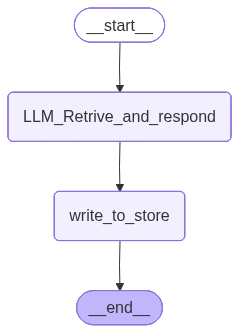

In [18]:
from langchain_core.messages import HumanMessage , SystemMessage
from langgraph.graph import MessagesState , StateGraph , START , END
from langchain_core.runnables.config import RunnableConfig
from langgraph.store.base import BaseStore 

# Create a node for retrival

response_SysIstr = """ You are a helpul assistant with 'past(exisitng) memory: '{memory} who can provide helpful, factual information about the user. 
            If the memory exists , use it to personalize your response to the user. Sometimes 'memory' may not exist. """

# get structure output blue print
from pydantic import BaseModel
class LLM_Response(BaseModel):
    result: str

# create a node function for LLm reponse to user query after reviewing existing memory
def LLM_Retrive_and_respond(state:MessagesState , config: RunnableConfig, store: BaseStore):
    """Load memory from the store and use it to personalize the chatbot's response."""
    
    # capture user_id from the runnableConfig
    key = "user_memory"
    user_id = config['configurable']['user_id']
    namespace = ("memory" , user_id) # user and his memory

    # get existing memory
    existing_memory = store.get(namespace , key) # provide namespace  and key to get information
    
    # if memory exists
    if existing_memory:
        existing_memory_content = existing_memory.value.get("memory")
    else:
        existing_memory_content = "No existing memory"
    # get LLm response
    response = llm.invoke([SystemMessage(content=response_SysIstr.format(memory = existing_memory_content))] + state['messages'])
    return { 'messages' : [response] }

    
#----------------------------------------------------------------------------------------------------------------------------#

# create a node to write memory into the 
write_sys_instr1 = '''     You are collecting information about the user and his interests to personalize your responses.

CURRENT USER INFORMATION:
{memory}

INSTRUCTIONS:
1. Review the chat history below carefully
2. Identify new information about the user, such as:
   - Personal details (name, location)
   - Preferences (likes, dislikes)
   - Interests and hobbies
   - Past experiences
   - Goals or future plans
3. Merge any new information with existing memory
4. Format the memory as a clear, bulleted list
5. If new information conflicts with existing memory, keep the most recent version

Remember: Only include factual information directly stated by the user. Do not make assumptions or inferences.

Based on the chat history below, please update the user information:'''

write_sys_instr2 = ''' You are a memory‑review assistant. Your task is to analyze the current conversation messages or chat history and the existing memory store about the user. 
Compare both to detect new facts, preferences, interests, or updates about the user.
Here is the existing memory: {memory}

Output a bullet list summarizing ONLY new or changed information about the user. 
Each bullet should be short, factual, and written in natural language.

Follow these rules:
- Do not repeat existing memory items unless they have changed.
- if there is a confict , use updated or new information.
- Focus on new insights, preferences, goals, or behaviors revealed in the latest messages.
- Include any new interests, favorites, or contextual details that help personalize future interactions.
- Avoid speculation or assumptions; base your list strictly on observable information.
- Format output as a clean bullet list (no numbering, no extra commentary).
- merge old and new with updated information to write back to the memory store for future reference.
- do not ommit information
- chat history will be given to you.
''' 
# create blueprint for structured output
class Write_LLM(BaseModel):
    content: str

# create a node to write new momory into the store
def write_to_store(state:MessagesState , config: RunnableConfig , store: BaseStore):
    ''' reflect on the history and write the updated information about the user to the store'''

    user_id = config['configurable']["user_id"]
    key = "user_memory"
    namespace = ("memory" , user_id)

    # retrive memory from the store
    existing_memory = store.get(namespace , key)

    # extract memory content
    if existing_memory:
        existing_memory_content = existing_memory.value.get("memory")
    else:
        existing_memory_content = "No memory exists"

    # extract user information
    sys_info = SystemMessage(content= write_sys_instr2.format(memory = existing_memory_content))

    response = llm.with_structured_output(Write_LLM).invoke([sys_info]+ state['messages'])

    # Update store
    store.put(namespace , key , {'memory' : response.content })
    return state

    
#--------------------------------------------------------------------------------------------------#

# build graph
builder = StateGraph(MessagesState)

# add nodes
builder.add_node('LLM_Retrive_and_respond' , LLM_Retrive_and_respond)
builder.add_node('write_to_store' , write_to_store)

# add edges or flow
builder.set_entry_point('LLM_Retrive_and_respond')
builder.add_edge('LLM_Retrive_and_respond' , 'write_to_store')
builder.add_edge('write_to_store',END)

# create checkpointers for both session memory and Long term store memory
from langgraph.checkpoint.memory import MemorySaver

session_memory = MemorySaver() # within thread memory
Long_memory = InMemoryStore() # across session/thread memory

# compile with noth checkpointer for thread and store for across thread
graph = builder.compile(checkpointer=session_memory , store = Long_memory)

#view
from IPython.display import Image, display

display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

### Invoke graph

In [19]:
# create a thread Id for checkpointer and a user ID for Langgraph store

config = {'configurable':{'thread_id' : "1" , 'user_id': "1"}}

# user input
input_message = HumanMessage(content="Hi, I'm Diya. I love Pizza")

# invoke graph
chunks =[]
for chunk in graph.stream({'messages':[input_message]} , config , stream_mode="values"):
    chunks.append(chunk)
    print(chunk)

{'messages': [HumanMessage(content="Hi, I'm Diya. I love Pizza", additional_kwargs={}, response_metadata={}, id='2c329de6-4126-4146-9d81-0ede1a3f4c1f')]}
{'messages': [HumanMessage(content="Hi, I'm Diya. I love Pizza", additional_kwargs={}, response_metadata={}, id='2c329de6-4126-4146-9d81-0ede1a3f4c1f'), AIMessage(content=[{'type': 'text', 'text': "Hi Diya! It's nice to meet you. I've made a note that you love pizza—that's a classic favorite! \n\nSince I don't have any previous information about you, I'll keep this in mind as we chat. Do you have a favorite type of pizza, or are you a fan of everything?", 'extras': {'signature': 'EjQKMgEMOdbH8IBhUiA8Q7tweipCkgMJRUUlh4pdbte6WVHK31gBj1/ZvvQH8IbszF9p7jrS'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e8930-3fd8-7bf1-9155-faf8a8b3dded-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens'

In [20]:
for chunk in chunks:
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

Hi, I'm Diya. I love Pizza
================================== Ai Message ==================================

[{'type': 'text', 'text': "Hi Diya! It's nice to meet you. I've made a note that you love pizza—that's a classic favorite! \n\nSince I don't have any previous information about you, I'll keep this in mind as we chat. Do you have a favorite type of pizza, or are you a fan of everything?", 'extras': {'signature': 'EjQKMgEMOdbH8IBhUiA8Q7tweipCkgMJRUUlh4pdbte6WVHK31gBj1/ZvvQH8IbszF9p7jrS'}}]
================================== Ai Message ==================================

[{'type': 'text', 'text': "Hi Diya! It's nice to meet you. I've made a note that you love pizza—that's a classic favorite! \n\nSince I don't have any previous information about you, I'll keep this in mind as we chat. Do you have a favorite type of pizza, or are you a fan of everything?", 'extras': {'signature': 'EjQKMgEMOdbH8IBhUiA8Q7

## Continue converstation and watch the thread and store

In [21]:
input_message = HumanMessage(content="Its raining today. I love rain. I like the Roses when it rains")

# invoke graph
chunks =[]
for chunk in graph.stream({'messages':[input_message]} , config , stream_mode="values"):
    chunks.append(chunk)
    print(chunk)

{'messages': [HumanMessage(content="Hi, I'm Diya. I love Pizza", additional_kwargs={}, response_metadata={}, id='2c329de6-4126-4146-9d81-0ede1a3f4c1f'), AIMessage(content=[{'type': 'text', 'text': "Hi Diya! It's nice to meet you. I've made a note that you love pizza—that's a classic favorite! \n\nSince I don't have any previous information about you, I'll keep this in mind as we chat. Do you have a favorite type of pizza, or are you a fan of everything?", 'extras': {'signature': 'EjQKMgEMOdbH8IBhUiA8Q7tweipCkgMJRUUlh4pdbte6WVHK31gBj1/ZvvQH8IbszF9p7jrS'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e8930-3fd8-7bf1-9155-faf8a8b3dded-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 70, 'output_tokens': 72, 'total_tokens': 142, 'input_token_details': {'cache_read': 0}}), HumanMessage(content='Its raining today. I love rain. I like t

In [22]:

for msg in chunks[-1]['messages']:
    msg.pretty_print()

================================ Human Message =================================

Hi, I'm Diya. I love Pizza
================================== Ai Message ==================================

[{'type': 'text', 'text': "Hi Diya! It's nice to meet you. I've made a note that you love pizza—that's a classic favorite! \n\nSince I don't have any previous information about you, I'll keep this in mind as we chat. Do you have a favorite type of pizza, or are you a fan of everything?", 'extras': {'signature': 'EjQKMgEMOdbH8IBhUiA8Q7tweipCkgMJRUUlh4pdbte6WVHK31gBj1/ZvvQH8IbszF9p7jrS'}}]
================================ Human Message =================================

Its raining today. I love rain. I like the Roses when it rains
================================== Ai Message ==================================

[{'type': 'text', 'text': "It sounds like such a cozy day, Diya! There is something so peaceful about the smell of rain and the way it makes the colors of roses pop. \n\nI’ve updated my notes

### check for chat history in the thread for session memory


In [23]:
chat_history =graph.get_state(config)
for msg in chat_history.values['messages']:
    msg.pretty_print()

================================ Human Message =================================

Hi, I'm Diya. I love Pizza
================================== Ai Message ==================================

[{'type': 'text', 'text': "Hi Diya! It's nice to meet you. I've made a note that you love pizza—that's a classic favorite! \n\nSince I don't have any previous information about you, I'll keep this in mind as we chat. Do you have a favorite type of pizza, or are you a fan of everything?", 'extras': {'signature': 'EjQKMgEMOdbH8IBhUiA8Q7tweipCkgMJRUUlh4pdbte6WVHK31gBj1/ZvvQH8IbszF9p7jrS'}}]
================================ Human Message =================================

Its raining today. I love rain. I like the Roses when it rains
================================== Ai Message ==================================

[{'type': 'text', 'text': "It sounds like such a cozy day, Diya! There is something so peaceful about the smell of rain and the way it makes the colors of roses pop. \n\nI’ve updated my notes

### Check if memory was saved to the store

In [24]:
user_id = config['configurable']['user_id']
user_id

'1'

In [25]:
# create a namespace
key = 'user_memory'
namespace = ('memory', user_id)
existing_memory = Long_memory.get(namespace , key)
existing_memory.dict() # convert to a dict

{'namespace': ['memory', '1'],
 'key': 'user_memory',
 'value': {'memory': "The user's name is Diya. Diya loves pizza. Diya loves the rain. Diya enjoys roses when it rains."},
 'created_at': '2026-06-02T16:35:16.947798+00:00',
 'updated_at': '2026-06-02T16:35:16.947798+00:00'}

## Start a new thread for the same user 

In [26]:
# set config with new thread but same user profile
config = {'configurable': {'thread_id': "2" , 'user_id': "1"}}

# set inout msg
input_msg = HumanMessage(content="Hi, good to see you. Now my favorite dish is Biriyani")

# run graph
for chunk in graph.stream({'messages': [input_msg] } , config , stream_mode="values"):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

Hi, good to see you. Now my favorite dish is Biriyani
================================== Ai Message ==================================

[{'type': 'text', 'text': "Hi Diya! It’s great to see you too.\n\nI’ve updated my notes—I’ll remember that Biriyani is now your favorite dish! It’s a delicious choice. Even though your favorite dish has changed, I’ll still keep in mind how much you love the rain and the way roses look when it’s pouring outside. \n\nIs there anything else you'd like to chat about today?", 'extras': {'signature': 'EjQKMgEMOdbHDlO9xlLudZpPo/hCyhDqWv7wc1cpqWCbo3l9Raq7NAJtlDAzZqxv8NnSHCSm'}}]
================================== Ai Message ==================================

[{'type': 'text', 'text': "Hi Diya! It’s great to see you too.\n\nI’ve updated my notes—I’ll remember that Biriyani is now your favorite dish! It’s a delicious choice. Even though your favorite dish has changed, I’ll still k

### Check out the store

In [27]:
user_id = config['configurable']['user_id']
key ='user_memory'
namespace = ('memory' , user_id)

existing_memory = Long_memory.get(namespace , key)
existing_memory.dict()

{'namespace': ['memory', '1'],
 'key': 'user_memory',
 'value': {'memory': "The user's name is Diya. Diya loves the rain. Diya enjoys roses when it rains. Diya's favorite dish is now Biriyani."},
 'created_at': '2026-06-02T16:36:04.009510+00:00',
 'updated_at': '2026-06-02T16:36:04.009510+00:00'}

### continue the conversation

In [28]:
# set config with new thread but same user profile
config = {'configurable': {'thread_id': "3" , 'user_id': "1"}}

# set inout msg
input_msg = HumanMessage(content="I was thinking of going out for dinner this evening. Need restaurant suggesion.")

# run graph
for chunk in graph.stream({'messages': [input_msg] } , config , stream_mode="values"):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

I was thinking of going out for dinner this evening. Need restaurant suggesion.
================================== Ai Message ==================================

[{'type': 'text', 'text': "Hi Diya! Since you're planning to go out for dinner, I’d love to help you find the perfect spot.\n\nGiven that your favorite dish is **Biriyani**, are you looking for a place that specializes in authentic, aromatic Biriyani? \n\nAlso, since I know you **love the rain** and enjoy the sight of **roses** when it’s raining, would you prefer a restaurant with a nice outdoor seating area or a garden view? If the weather forecast shows rain for this evening, finding a spot with a cozy, floral-filled patio might make your dinner extra special!\n\nLet me know which city or neighborhood you are in, and I can give you some specific recommendations!", 'extras': {'signature': 'EjQKMgEMOdbHNwoYFVmw78HfCrCy70sA40lcpF7Ilmd3jBP1PCjPPC2z

In [29]:

existing_memory = Long_memory.get(namespace , key)
existing_memory.dict()

{'namespace': ['memory', '1'],
 'key': 'user_memory',
 'value': {'memory': "Diya's name is Diya. Diya loves the rain. Diya enjoys roses when it rains. Diya's favorite dish is Biriyani."},
 'created_at': '2026-06-02T16:36:27.781520+00:00',
 'updated_at': '2026-06-02T16:36:27.781520+00:00'}

In [30]:
# set config with new thread but same user profile
config = {'configurable': {'thread_id': "4" , 'user_id': "1"}}

# set inout msg
input_msg = HumanMessage(content="i loved the pizza i ate today. what is my favorite food? ")

# run graph
for chunk in graph.stream({'messages': [input_msg] } , config , stream_mode="values"):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

i loved the pizza i ate today. what is my favorite food? 
================================== Ai Message ==================================

[{'type': 'text', 'text': 'That sounds like a delicious meal! Even though you enjoyed that pizza today, your favorite dish is actually Biriyani.', 'extras': {'signature': 'EjQKMgEMOdbH+/b9RLLjcxbO2bObqBewYBtyvhq3p0dv+XoHas+g2Mmkq3agnT97mMy5s7t/'}}]
================================== Ai Message ==================================

[{'type': 'text', 'text': 'That sounds like a delicious meal! Even though you enjoyed that pizza today, your favorite dish is actually Biriyani.', 'extras': {'signature': 'EjQKMgEMOdbH+/b9RLLjcxbO2bObqBewYBtyvhq3p0dv+XoHas+g2Mmkq3agnT97mMy5s7t/'}}]


In [31]:

existing_memory = Long_memory.get(namespace , key)
existing_memory.dict()

{'namespace': ['memory', '1'],
 'key': 'user_memory',
 'value': {'memory': "Diya's name is Diya. Diya loves the rain. Diya enjoys roses when it rains. Diya's favorite dish is Biriyani. Diya recently enjoyed eating pizza."},
 'created_at': '2026-06-02T16:36:47.285739+00:00',
 'updated_at': '2026-06-02T16:36:47.285739+00:00'}

## langgraph tracing
https://smith.langchain.com/public/